In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    parent_root = project_root.parent
    if (parent_root / "src").exists():
        project_root = parent_root

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Using project root: {project_root}")

Using project root: c:\Users\teMelkishi\Desktop\projects\tenx\projects\news-driven-stock-analysis


In [2]:
import pandas as pd
from src.data_loader import load_data
from src.analysis import normalize_timestamps


In [3]:
# Load news data
news = pd.read_csv('../data/news_raw_data.csv')
news_df = pd.DataFrame(news)
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# APPLE

In [4]:
aapl_news_df = news_df[news_df['stock'] == 'AAPL']
aapl_news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
6680,7120,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 11:33:26-04:00,AAPL
6681,7121,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 08:14:08-04:00,AAPL
6682,7122,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 07:53:47-04:00,AAPL
6683,7123,"Deutsche Bank Maintains Buy on Apple, Raises P...",https://www.benzinga.com/news/20/06/16219873/d...,Benzinga Newsdesk,2020-06-10 07:19:25-04:00,AAPL
6684,7124,Apple To Let Users Trade In Their Mac Computer...,https://www.benzinga.com/news/20/06/16218697/a...,Neer Varshney,2020-06-10 06:27:11-04:00,AAPL


In [5]:
# Load AAPL stock data
aapl_df = load_data(filepath='../data/finance-data/AMZN.csv')
aapl_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.718,2.7265,2.5535,2.5675,145928000.0
2009-01-05,2.703,2.7870,2.6515,2.7865,190196000.0
2009-01-06,2.868,2.9110,2.6875,2.7275,221602000.0
2009-01-07,2.810,2.8475,2.7675,2.8145,158854000.0
2009-01-08,2.858,2.8660,2.7290,2.7495,131558000.0


In [6]:
# Call normalize_timestamps with aapl_news_df and stock_df
normalized_news = normalize_timestamps(
    stock_df=aapl_df.reset_index().copy(),
    news_df=aapl_news_df.copy(),
    sticker='AAPL',
    news_date_col='date',
    stock_date_col='Date'
)
normalized_news.head()


News timestamps after timezone normalization:
6680   2020-06-10 15:33:26
6681   2020-06-10 12:14:08
6682   2020-06-10 11:53:47
6683   2020-06-10 11:19:25
6684   2020-06-10 10:27:11
Name: date, dtype: datetime64[ns]

AAPL Stock timestamps after timezone normalization:
0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


,Unnamed: 0,headline,url,publisher,date,stock,trading_date
6680,7120,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26,AAPL,2020-06-10
6681,7121,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 12:14:08,AAPL,2020-06-10
6682,7122,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47,AAPL,2020-06-10
6683,7123,"Deutsche Bank Maintains Buy on Apple, Raises P...",https://www.benzinga.com/news/20/06/16219873/d...,Benzinga Newsdesk,2020-06-10 11:19:25,AAPL,2020-06-10
6684,7124,Apple To Let Users Trade In Their Mac Computer...,https://www.benzinga.com/news/20/06/16218697/a...,Neer Varshney,2020-06-10 10:27:11,AAPL,2020-06-10


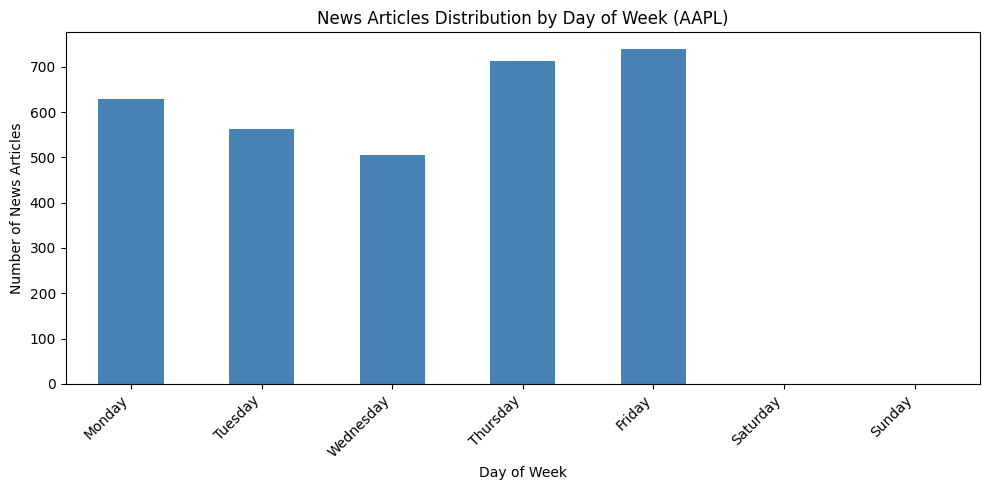

In [20]:
import matplotlib.pyplot as plt

# Convert trading_date to datetime and extract day of week
normalized_news['trading_date'] = pd.to_datetime(normalized_news['trading_date'])
news_by_day = normalized_news['trading_date'].dt.day_name().value_counts()

# Reorder by day of week (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
news_by_day = news_by_day.reindex(day_order)

plt.figure(figsize=(10, 5))
news_by_day.plot(kind='bar', color='steelblue')
plt.xlabel('Day of Week')
plt.ylabel('Number of News Articles')
plt.title('News Articles Distribution by Day of Week (AAPL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# AMAZON

In [7]:
amzn_news_df = news_df[news_df['stock'] == 'AMZN']
amzn_news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
76177,76869,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 13:18:50-04:00,AMZN
76178,76870,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 11:33:26-04:00,AMZN
76179,76871,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 07:53:47-04:00,AMZN
76180,76872,"Hearing Vertical Group Out Positive On Amazon,...",https://www.benzinga.com/analyst-ratings/analy...,Benzinga Newsdesk,2020-06-10 07:20:03-04:00,AMZN
76181,76873,Big Tech Reaches New Record Heights At The Sto...,https://www.benzinga.com/news/20/06/16218615/b...,Neer Varshney,2020-06-10 00:52:01-04:00,AMZN


In [8]:
# Load AMZN stock data
amzn_df = load_data(filepath='../data/finance-data/AMZN.csv')
amzn_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.718,2.7265,2.5535,2.5675,145928000.0
2009-01-05,2.703,2.7870,2.6515,2.7865,190196000.0
2009-01-06,2.868,2.9110,2.6875,2.7275,221602000.0
2009-01-07,2.810,2.8475,2.7675,2.8145,158854000.0
2009-01-08,2.858,2.8660,2.7290,2.7495,131558000.0


In [9]:
# Call normalize_timestamps with amzn_news_df and stock_df
normalized_news = normalize_timestamps(
    stock_df=amzn_df.reset_index().copy(),
    news_df=amzn_news_df.copy(),
    sticker='AMZN',
    news_date_col='date',
    stock_date_col='Date'
)
normalized_news.head()


News timestamps after timezone normalization:
76177   2020-06-10 17:18:50
76178   2020-06-10 15:33:26
76179   2020-06-10 11:53:47
76180   2020-06-10 11:20:03
76181   2020-06-10 04:52:01
Name: date, dtype: datetime64[ns]

AMZN Stock timestamps after timezone normalization:
0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


,Unnamed: 0,headline,url,publisher,date,stock,trading_date
76177,76869,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 17:18:50,AMZN,2020-06-10
76178,76870,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26,AMZN,2020-06-10
76179,76871,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47,AMZN,2020-06-10
76180,76872,"Hearing Vertical Group Out Positive On Amazon,...",https://www.benzinga.com/analyst-ratings/analy...,Benzinga Newsdesk,2020-06-10 11:20:03,AMZN,2020-06-10
76181,76873,Big Tech Reaches New Record Heights At The Sto...,https://www.benzinga.com/news/20/06/16218615/b...,Neer Varshney,2020-06-10 04:52:01,AMZN,2020-06-10


# GOOGLE

In [10]:
goog_news_df = news_df[news_df['stock'] == 'GOOG']
goog_news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
565380,568379,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 15:25:13-04:00,GOOG
565381,568380,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 13:18:50-04:00,GOOG
565382,568381,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 00:28:00-04:00,GOOG
565383,568382,Price Over Earnings Overview: Alphabet,https://www.benzinga.com/intraday-update/20/06...,Benzinga Insights,2020-06-09 14:39:26-04:00,GOOG
565384,568383,Google Maps To Offer Relevant Local COVID-19 I...,https://www.benzinga.com/news/20/06/16208274/g...,Shivdeep Dhaliwal,2020-06-09 03:51:41-04:00,GOOG


In [11]:
# Load GOOG stock data
goog_df = load_data(filepath='../data/finance-data/GOOG.csv')
goog_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322.0
2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007.0
2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329.0
2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860.0
2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852.0


In [12]:
# Call normalize_timestamps with goog_news_df and stock_df
normalized_news = normalize_timestamps(
    stock_df=goog_df.reset_index().copy(),
    news_df=goog_news_df.copy(),
    sticker='GOOG',
    news_date_col='date',
    stock_date_col='Date'
)
normalized_news.head()


News timestamps after timezone normalization:
565380   2020-06-10 19:25:13
565381   2020-06-10 17:18:50
565382   2020-06-10 04:28:00
565383   2020-06-09 18:39:26
565384   2020-06-09 07:51:41
Name: date, dtype: datetime64[ns]

GOOG Stock timestamps after timezone normalization:
0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


,Unnamed: 0,headline,url,publisher,date,stock,trading_date
565380,568379,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 19:25:13,GOOG,2020-06-10
565381,568380,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 17:18:50,GOOG,2020-06-10
565382,568381,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 04:28:00,GOOG,2020-06-10
565383,568382,Price Over Earnings Overview: Alphabet,https://www.benzinga.com/intraday-update/20/06...,Benzinga Insights,2020-06-09 18:39:26,GOOG,2020-06-09
565384,568383,Google Maps To Offer Relevant Local COVID-19 I...,https://www.benzinga.com/news/20/06/16208274/g...,Shivdeep Dhaliwal,2020-06-09 07:51:41,GOOG,2020-06-09


# META

In [13]:
meta_news_df = news_df[news_df['stock'] == 'M']
meta_news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
787099,791053,Shares of several retail & apparel companies a...,https://www.benzinga.com/wiim/20/06/16233472/s...,Benzinga Newsdesk,2020-06-11 10:34:01-04:00,M
787100,791054,Shares of retail & apparel companies are tradi...,https://www.benzinga.com/wiim/20/06/16222702/s...,Benzinga Newsdesk,2020-06-10 10:36:34-04:00,M
787101,791055,Credit Suisse Maintains Underperform on Macy's...,https://www.benzinga.com/news/20/06/16220945/c...,Benzinga Newsdesk,2020-06-10 08:56:39-04:00,M
787102,791056,Morgan Stanley Maintains Underweight on Macy's...,https://www.benzinga.com/news/20/06/16220514/m...,Benzinga Newsdesk,2020-06-10 08:09:50-04:00,M
787103,791057,Diversity And Inclusion In Macy's DNA For Year...,https://www.benzinga.com/news/20/06/16218669/d...,Shivdeep Dhaliwal,2020-06-10 05:26:13-04:00,M


In [14]:
# Load META stock data
meta_df = load_data(filepath='../data/finance-data/META.csv')
meta_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400.0
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700.0
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600.0
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000.0
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200.0


In [15]:
# Call normalize_timestamps with meta_news_df and stock_df
normalized_news = normalize_timestamps(
    stock_df=meta_df.reset_index().copy(),
    news_df=meta_news_df.copy(),
    sticker='META',
    news_date_col='date',
    stock_date_col='Date'
)
normalized_news.head()


News timestamps after timezone normalization:
787099   2020-06-11 14:34:01
787100   2020-06-10 14:36:34
787101   2020-06-10 12:56:39
787102   2020-06-10 12:09:50
787103   2020-06-10 09:26:13
Name: date, dtype: datetime64[ns]

META Stock timestamps after timezone normalization:
0   2012-05-18
1   2012-05-21
2   2012-05-22
3   2012-05-23
4   2012-05-24
Name: Date, dtype: datetime64[ns]


,Unnamed: 0,headline,url,publisher,date,stock,trading_date
787099,791053,Shares of several retail & apparel companies a...,https://www.benzinga.com/wiim/20/06/16233472/s...,Benzinga Newsdesk,2020-06-11 14:34:01,M,2020-06-11
787100,791054,Shares of retail & apparel companies are tradi...,https://www.benzinga.com/wiim/20/06/16222702/s...,Benzinga Newsdesk,2020-06-10 14:36:34,M,2020-06-10
787101,791055,Credit Suisse Maintains Underperform on Macy's...,https://www.benzinga.com/news/20/06/16220945/c...,Benzinga Newsdesk,2020-06-10 12:56:39,M,2020-06-10
787102,791056,Morgan Stanley Maintains Underweight on Macy's...,https://www.benzinga.com/news/20/06/16220514/m...,Benzinga Newsdesk,2020-06-10 12:09:50,M,2020-06-10
787103,791057,Diversity And Inclusion In Macy's DNA For Year...,https://www.benzinga.com/news/20/06/16218669/d...,Shivdeep Dhaliwal,2020-06-10 09:26:13,M,2020-06-10


# NVDA

In [16]:
nvda_news_df = news_df[news_df['stock'] == 'NVDA']
nvda_news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
924271,929039,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/06/16224173/s...,Benzinga Newsdesk,2020-06-10 12:37:10-04:00,NVDA
924272,929040,Afternoon Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1622357...,Benzinga Insights,2020-06-10 12:12:25-04:00,NVDA
924273,929041,Morning Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1622174...,Benzinga Insights,2020-06-10 10:22:11-04:00,NVDA
924274,929042,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/06/16214789/s...,Benzinga Newsdesk,2020-06-09 13:40:43-04:00,NVDA
924275,929043,Afternoon Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1620319...,Benzinga Insights,2020-06-08 12:30:29-04:00,NVDA


In [17]:
# Load NVDA stock data
nvda_df = load_data(filepath='../data/finance-data/NVDA.csv')
nvda_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,0.199652,0.201027,0.184294,0.184982,4.971240e+08
2009-01-05,0.203319,0.207904,0.195984,0.197360,7.057360e+08
2009-01-06,0.210196,0.216156,0.204695,0.209279,6.579040e+08
2009-01-07,0.197589,0.205382,0.190483,0.205382,8.700960e+08
2009-01-08,0.192546,0.195067,0.180626,0.195067,1.014496e+09


In [18]:
# Call normalize_timestamps with amzn_news_df and stock_df
normalized_news = normalize_timestamps(
    stock_df=nvda_df.reset_index().copy(),
    news_df=nvda_news_df.copy(),
    sticker='NVDA',
    news_date_col='date',
    stock_date_col='Date'
)
normalized_news.head()


News timestamps after timezone normalization:
924271   2020-06-10 16:37:10
924272   2020-06-10 16:12:25
924273   2020-06-10 14:22:11
924274   2020-06-09 17:40:43
924275   2020-06-08 16:30:29
Name: date, dtype: datetime64[ns]

NVDA Stock timestamps after timezone normalization:
0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


,Unnamed: 0,headline,url,publisher,date,stock,trading_date
924271,929039,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/06/16224173/s...,Benzinga Newsdesk,2020-06-10 16:37:10,NVDA,2020-06-10
924272,929040,Afternoon Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1622357...,Benzinga Insights,2020-06-10 16:12:25,NVDA,2020-06-10
924273,929041,Morning Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1622174...,Benzinga Insights,2020-06-10 14:22:11,NVDA,2020-06-10
924274,929042,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/06/16214789/s...,Benzinga Newsdesk,2020-06-09 17:40:43,NVDA,2020-06-09
924275,929043,Afternoon Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1620319...,Benzinga Insights,2020-06-08 16:30:29,NVDA,2020-06-08
